# 📡 API Pagination Extractor

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-engineering-pro/api-paginator/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-engineering-pro/api-paginator/demo.ipynb)

**Pain point:** *"Paginated API pulls are hand-coded each time."*

One generic extractor that speaks all four pagination dialects — offset/limit, page/per_page, cursor tokens, and link-follow — with 429 rate-limit retry/backoff built in. Tested offline against a mock API that serves the same data in every style.

**What this notebook covers:**
1. The extractor — four strategies, one retry loop
2. The mock API (with injected 429s)
3. Extracting the same 950 records via all four styles
4. Completeness proof + request accounting
5. Try it against your real API


## Step 1 — The extractor

Every SaaS API paginates one of four ways:

| Strategy | Request params | Stop condition |
|---|---|---|
| `offset` | `?offset=200&limit=100` | page shorter than limit |
| `page` | `?page=3&per_page=100` | page shorter than per_page |
| `cursor` | `?cursor=abc123` | `next_cursor` is null |
| `link` | follow `next_url` | no next link |

`paginate()` takes a `fetch_page(params) -> (json, status)` callable — requests, httpx, or a mock — and handles the loop, the stop condition, **429s with Retry-After + exponential backoff**, and a `max_pages` cap against runaway loops. Stats record every request, retry, and page size.


In [1]:
from __future__ import annotations

from dataclasses import dataclass, field
from typing import Callable, Dict, List, Optional, Tuple


@dataclass
class FetchStats:
    requests: int = 0
    retries: int = 0
    rate_limited: int = 0
    items: int = 0
    pages: List[int] = field(default_factory=list)  # items per successful page


class RetryError(RuntimeError):
    pass


def paginate(fetch_page: Callable[[Dict], Tuple[Dict, int]], strategy: str,
             page_size: int = 100, max_pages: int = 1000, max_retries: int = 4,
             items_key: str = "items", cursor_key: str = "next_cursor",
             sleep_fn: Callable[[float], None] = lambda s: None) -> Tuple[List[Dict], FetchStats]:
    """Generic paginated extractor.

    fetch_page(params) -> (json_dict, status_code). Strategies:
      - offset:  params {offset, limit}; stop when a page returns < limit items
      - page:    params {page, per_page}; stop when a page returns < per_page items
      - cursor:  params {cursor, limit}; follow json[cursor_key] until null
      - link:    params {url}; follow json['next_url'] until null (Link-header style)

    429 responses honor Retry-After via sleep_fn and retry with exponential backoff,
    up to max_retries per page. max_pages caps runaway loops.
    """
    if strategy not in ("offset", "page", "cursor", "link"):
        raise ValueError(f"unknown strategy: {strategy}")

    stats = FetchStats()
    items: List[Dict] = []
    offset, page_num = 0, 1
    cursor: Optional[str] = None
    url: Optional[str] = "/v1/records"

    def call(params: Dict) -> Dict:
        delay = 0.5
        for attempt in range(max_retries + 1):
            stats.requests += 1
            body, status = fetch_page(params)
            if status == 200:
                return body
            if status == 429:
                stats.rate_limited += 1
                stats.retries += 1
                sleep_fn(float(body.get("retry_after", delay)))
                delay *= 2
                continue
            raise RetryError(f"HTTP {status} on {params}")
        raise RetryError(f"gave up after {max_retries} retries on {params}")

    for _ in range(max_pages):
        if strategy == "offset":
            body = call({"offset": offset, "limit": page_size})
        elif strategy == "page":
            body = call({"page": page_num, "per_page": page_size})
        elif strategy == "cursor":
            body = call({"cursor": cursor, "limit": page_size})
        else:
            if url is None:
                break
            body = call({"url": url})

        batch = body.get(items_key, [])
        items.extend(batch)
        stats.items += len(batch)
        stats.pages.append(len(batch))

        if strategy == "offset":
            if len(batch) < page_size:
                break
            offset += page_size
        elif strategy == "page":
            if len(batch) < page_size:
                break
            page_num += 1
        elif strategy == "cursor":
            cursor = body.get(cursor_key)
            if not cursor:
                break
        else:
            url = body.get("next_url")
            if not url:
                break
    return items, stats


class MockAPI:
    """In-memory API serving the same dataset via all four pagination styles,
    with configurable flaky 429s — so the extractor is testable offline."""

    def __init__(self, n_records: int = 950, flaky_429_every: int = 0, seed: int = 5) -> None:
        import random
        self.records = [{"id": i, "name": f"rec-{i:04d}", "value": round(i * 1.7, 1)}
                        for i in range(1, n_records + 1)]
        self._rng = random.Random(seed)
        self.flaky_429_every = flaky_429_every
        self._calls = 0

    def _maybe_429(self) -> bool:
        self._calls += 1
        return self.flaky_429_every > 0 and self._calls % self.flaky_429_every == 0

    def fetch(self, params: Dict) -> Tuple[Dict, int]:
        if self._maybe_429():
            return {"error": "rate limited", "retry_after": 0.01}, 429

        if "offset" in params:
            lo, n = params["offset"], params["limit"]
            return {"items": self.records[lo:lo + n]}, 200

        if "page" in params:
            n = params["per_page"]
            lo = (params["page"] - 1) * n
            return {"items": self.records[lo:lo + n]}, 200

        if "cursor" in params:
            n = params["limit"]
            lo = int(params["cursor"] or 0)
            batch = self.records[lo:lo + n]
            nxt = str(lo + n) if lo + n < len(self.records) else None
            return {"items": batch, "next_cursor": nxt}, 200

        if "url" in params:
            from urllib.parse import parse_qs, urlparse
            q = parse_qs(urlparse(params["url"]).query)
            lo = int(q.get("after", ["0"])[0])
            n = int(q.get("limit", ["100"])[0])
            batch = self.records[lo:lo + n]
            nxt = f"/v1/records?after={lo + n}&limit={n}" if lo + n < len(self.records) else None
            return {"items": batch, "next_url": nxt}, 200

        return {"error": "bad request"}, 400


## Step 2 — Extract via all four dialects

950 records behind the mock API, page size 100, and a 429 injected every 7th call — the flaky reality of SaaS APIs.

In [2]:
results = {}
for strategy in ("offset", "page", "cursor", "link"):
    api = MockAPI(n_records=950, flaky_429_every=7)
    items, stats = paginate(api.fetch, strategy, page_size=100)
    results[strategy] = (items, stats)
    print(f"{strategy:7s} → {stats.items} items in {stats.requests} requests "
          f"({stats.retries} retries, {stats.rate_limited} × 429)")

offset  → 950 items in 11 requests (1 retries, 1 × 429)
page    → 950 items in 11 requests (1 retries, 1 × 429)
cursor  → 950 items in 11 requests (1 retries, 1 × 429)
link    → 950 items in 11 requests (1 retries, 1 × 429)


## Step 3 — Completeness proof

An extractor that silently drops or duplicates a page is worse than a hand-coded one. Assert: every strategy returns exactly the full record set, in order, no dupes.

In [3]:
expected = list(range(1, 951))
for strategy, (items, stats) in results.items():
    ids = [i["id"] for i in items]
    assert ids == expected, f"{strategy}: incomplete or duplicated!"
print("✅ all four strategies: 950/950 records, ordered, no duplicates, 429s absorbed")

✅ all four strategies: 950/950 records, ordered, no duplicates, 429s absorbed


## Step 4 — Request accounting

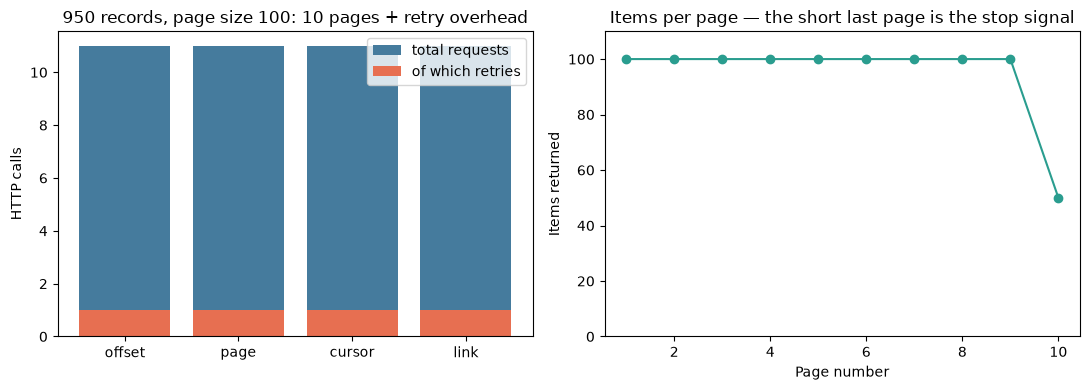

In [4]:
import matplotlib.pyplot as plt
import numpy as np

strategies = list(results)
requests = [results[s][1].requests for s in strategies]
retries = [results[s][1].retries for s in strategies]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
x = np.arange(len(strategies))
ax1.bar(x, requests, color="#457b9d", label="total requests")
ax1.bar(x, retries, color="#e76f51", label="of which retries")
ax1.set_xticks(x)
ax1.set_xticklabels(strategies)
ax1.set_ylabel("HTTP calls")
ax1.set_title("950 records, page size 100: 10 pages + retry overhead")
ax1.legend()

pages = results["cursor"][1].pages
ax2.plot(range(1, len(pages) + 1), pages, marker="o", color="#2a9d8f")
ax2.set_xlabel("Page number")
ax2.set_ylabel("Items returned")
ax2.set_title("Items per page — the short last page is the stop signal")
ax2.set_ylim(0, 110)

fig.tight_layout()
fig.savefig("pagination_stats.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

| Guarantee | How |
|---|---|
| Works on any API | inject your own `fetch_page` callable |
| All four dialects | offset / page / cursor / link, one interface |
| Rate limits | 429 → honor Retry-After, exponential backoff, capped retries |
| No runaway loops | `max_pages` guard |
| Provable extraction | stats per page + completeness assertion |

Write the pull once; the next paginated API is a one-line strategy change instead of another afternoon of loop-and-pray.


## Try it against a real API

In [5]:
# import requests
#
# def fetch_github(params):
#     r = requests.get("https://api.github.com/repos/pandas-dev/pandas/issues",
#                      params={"page": params["page"], "per_page": params["per_page"]},
#                      headers={"Accept": "application/vnd.github+json"})
#     return {"items": r.json()}, r.status_code
#
# issues, stats = paginate(fetch_github, "page", page_size=50, max_pages=4)
# print(len(issues), "issues in", stats.requests, "requests")

---

Part of **[Phoebe the Builder](https://github.com/phoebefu6/phoebe-the-builder)** — Portfolio 2: routine data/AI task coverage.

Prefer a UI? Run the Streamlit version:

```bash
pip install -r requirements.txt
streamlit run app.py
```
